In [1]:
import scipy.stats as stats
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from _helper_functions import *

In [2]:
df=pd.read_pickle('02-Syntax-Scores/3i-all-seqs.fillNaN.effectSize=odds-ratio.pandas.dataframe.pickle').reset_index()
df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,[nan],NaN,1.0


In [3]:
fn=f'01-Barcode-Processing/endf_final-experiment-enhancer-activity_usable-sites-annotated.pd.df.pickle'
endf=pd.read_pickle(fn).reset_index(drop=True)
endf=endf.loc[endf['num-tot-olap']==0,:]
endf.head(1)

,enhancer-seq,enhancer-id,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65,site-idx-list-callable,site-idx-list-callable-distinct,num-gata-distinct,num-ets-distinct,num-tot-distinct,num-tot-olap,gata-affs,ets-affs
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,Chr8:6147080-6147146,-3.625061,"[0, 1, 3]","[0, 1, 3]",1,2,3,0,"[(43, 0.6840717119380976), (57, 0.068388365178...","[(32, 0.2500506805527969), (58, 0.388798164442..."


In [4]:
controls=['OSL12',
'OSL17 ABL',
'OSL42',
'OSL43',
'OSL5',
'Otx-a WT']

endf=endf.loc[~endf['enhancer-id'].isin(controls),:]


In [5]:
len(endf)

3312

In [6]:
# merge enhancer data with the syntax scores
df=df.merge(endf,left_on='seq',right_on='enhancer-seq')
df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1,enhancer-seq,enhancer-id,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65,site-idx-list-callable,site-idx-list-callable-distinct,num-gata-distinct,num-ets-distinct,num-tot-distinct,num-tot-olap,gata-affs,ets-affs
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,[nan],NaN,1.0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,Chr8:6147080-6147146,-3.625061,"[0, 1, 3]","[0, 1, 3]",1,2,3,0,"[(43, 0.6840717119380976), (57, 0.068388365178...","[(32, 0.2500506805527969), (58, 0.388798164442..."


In [7]:
df['syntax-score']=df['Ma-sum-nafill1']

# Calculate aggregate element affinity

In [8]:
etssum=[]
gatasum=[]

for gafflist,eafflist in zipdf(df,['gata-affs','ets-affs']):
    
    gafflist=[aff for idx,aff in gafflist if aff>.2]
    eafflist=[aff for idx,aff in eafflist if aff>.1]
    
    gatasum.append(sum(gafflist))
    etssum .append(sum(eafflist))
    
    
df['ets-aggaff']=etssum
df['gata-aggaff']=gatasum

In [9]:

# group elements into aggregate affinity bins 

affbinsets=[0,.5,np.inf]
affbinsgata=[0,.55,1.1,np.inf]
    
affbinsetslabels=[f'{round(affbinsets[i],2)}-{round(affbinsets[i+1],2)}' for i in range(len(affbinsets)-1)]
affbinsgatalabels=[f'{round(affbinsgata[i],2)}-{round(affbinsgata[i+1],2)}' for i in range(len(affbinsgata)-1)]
    
print('ets',affbinsetslabels)
print('gata',affbinsgatalabels)
    

df['ets-aggaff-bin']  = pd.cut(df['ets-aggaff'], 
                                  bins=affbinsets,labels=range(len(affbinsets)-1))

df['gata-aggaff-bin'] = pd.cut(df['gata-aggaff'], 
                                  bins=affbinsgata,labels=range(len(affbinsgata)-1))


df.head()


ets ['0-0.5', '0.5-inf']
gata ['0-0.55', '0.55-1.1', '1.1-inf']


,seq,Ma,Ma-sum,Ma-sum-nafill1,enhancer-seq,enhancer-id,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65,site-idx-list-callable,site-idx-list-callable-distinct,num-gata-distinct,num-ets-distinct,num-tot-distinct,num-tot-olap,gata-affs,ets-affs,syntax-score,ets-aggaff,gata-aggaff,ets-aggaff-bin,gata-aggaff-bin
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,[nan],NaN,1.000000,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,Chr8:6147080-6147146,-3.625061,"[0, 1, 3]","[0, 1, 3]",1,2,3,0,"[(43, 0.6840717119380976), (57, 0.068388365178...","[(32, 0.2500506805527969), (58, 0.388798164442...",1.000000,0.638849,0.684072,1,1
1,AAAAAATGCTGTGTATATCCTTTTGAGTTGGTGACAGTGATATTAT...,"[1.429570971547928, 1.7754848444025328]",3.205056,3.205056,AAAAAATGCTGTGTATATCCTTTTGAGTTGGTGACAGTGATATTAT...,Chr10:4757123-4757189,-4.852405,"[1, 2, 3]","[1, 2, 3]",2,1,3,0,"[(13, 0.09778177366631857), (36, 0.25584642761...","[(14, 0.1701970705616634)]",3.205056,0.170197,0.919057,0,1
2,AAAAAATTCCGGCCGATACGGTCAAGTTTAAAAAAAAATCCGGCAG...,[nan],NaN,1.000000,AAAAAATTCCGGCCGATACGGTCAAGTTTAAAAAAAAATCCGGCAG...,Chr1:10185315-10185381,-2.953075,"[0, 1, 2]","[0, 1, 2]",1,2,3,0,"[(12, 0.2121003959316691), (58, 0.089699291504...","[(4, 0.24553755172999858), (35, 0.250050680552...",1.000000,0.495588,0.212100,0,0
3,AAAAACGCAGATATGGTCACTAATAAACAAAATACATAGTTTAATT...,[1.1760316890378562],1.176032,1.176032,AAAAACGCAGATATGGTCACTAATAAACAAAATACATAGTTTAATT...,Chr8:5916117-5916183,9.109125,"[0, 1, 3]","[0, 1, 3]",1,2,3,0,"[(7, 0.5579541771045333), (47, 0.1556089578122...","[(46, 0.10718527376713156), (58, 0.11811179618...",1.176032,0.225297,0.557954,0,1
4,AAAAAGAGCGTTGGTAATTGTTCTAAACACAATCAGGAAATATGGG...,[nan],NaN,1.000000,AAAAAGAGCGTTGGTAATTGTTCTAAACACAATCAGGAAATATGGG...,Chr4:2831390-2831456,-1.122727,"[0, 1, 3]","[0, 1, 3]",1,2,3,0,"[(43, 0.054054301158468515), (58, 0.6455588210...","[(33, 0.5461269819167692), (42, 0.128569907423...",1.000000,0.674697,0.645559,1,1


In [10]:
df['activity']=df['ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65']
df.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1,enhancer-seq,enhancer-id,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65,site-idx-list-callable,site-idx-list-callable-distinct,num-gata-distinct,...,num-tot-distinct,num-tot-olap,gata-affs,ets-affs,syntax-score,ets-aggaff,gata-aggaff,ets-aggaff-bin,gata-aggaff-bin,activity
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,[nan],NaN,1.0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,Chr8:6147080-6147146,-3.625061,"[0, 1, 3]","[0, 1, 3]",1,...,3,0,"[(43, 0.6840717119380976), (57, 0.068388365178...","[(32, 0.2500506805527969), (58, 0.388798164442...",1.0,0.638849,0.684072,1,1,-3.625061


In [11]:

# nsites=3 # only 3 site clusters
nsites=34 # both 3 and 4 site clusters

if nsites==3:
    syntaxbins=[0,1,2.7,np.inf] # s.s. with 0-1 have no features at all (odds-ratio of 1 is no enrichment at all). s.s. >2.7 is above the ~80th percentile for 3- or 4-site clusters
        
elif nsites==34:
    syntaxbins=[0,1,3,np.inf]   # s.s. with 0-1 have no features at all (odds-ratio of 1 is no enrichment at all). s.s. >3 is above the ~80th percentile for 3- or 4-site clusters

df['syntax-score-bin']=pd.cut(df['syntax-score'],bins=syntaxbins,labels=[0,1,2])

df['syntax-score-bin'].value_counts()

# df.head()

syntax-score-bin
1    1646
0    1068
2     598
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


3A 815
3I 1316
4A 319
4I 471
site3A 0.382 815
site3I 0.618 1316
site4A 0.404 319
site4I 0.596 471


Text(0, 0.5, 'Proportion of active vs inert')

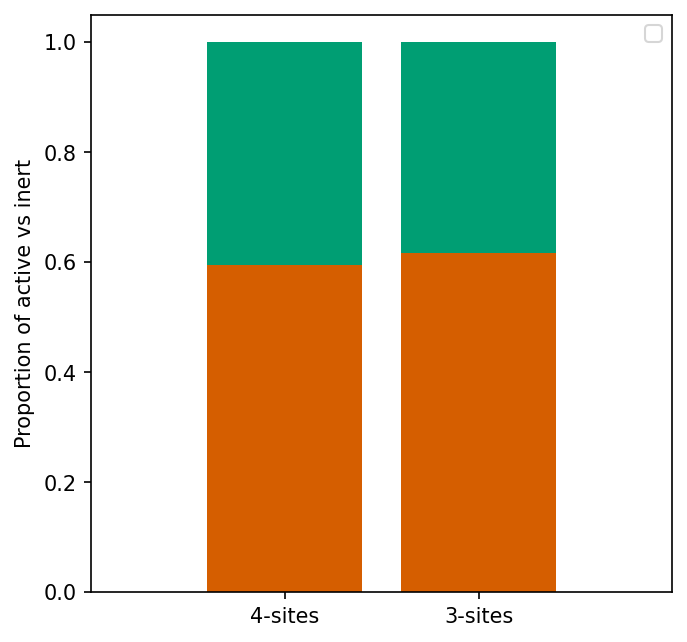

In [12]:
site3=endf['num-tot-distinct']==3
site4=endf['num-tot-distinct']==4

activeEns=endf['ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65']>=1
inertSeqs=endf['ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65']<=0
classified= activeEns | inertSeqs

site3A = sum(site3 & activeEns) / sum(site3 & classified)
site3I = sum(site3 & inertSeqs) / sum(site3 & classified)
site4A = sum(site4 & activeEns) / sum(site4 & classified)
site4I = sum(site4 & inertSeqs) / sum(site4 & classified)

fig,ax=quickfig()


print('3A', sum(site3 & activeEns))
print('3I', sum(site3 & inertSeqs))
print('4A', sum(site4 & activeEns))
print('4I', sum(site4 & inertSeqs))

print('site3A',round(site3A,3),sum(site3 & activeEns))
print('site3I',round(site3I,3),sum(site3 & inertSeqs))
print('site4A',round(site4A,3),sum(site4 & activeEns))
print('site4I',round(site4I,3),sum(site4 & inertSeqs))

ax.bar(0,site4I,color=cb['red'])
ax.bar(0,site4A,bottom=site4I,color=cb['green'])

ax.bar(1,site3I,color=cb['red'])
ax.bar(1,site3A,bottom=site3I,color=cb['green'])

ax.set_xlim(-1,2)
ax.set_xticks([0,1],labels=['4-sites','3-sites'])
ax.legend()
ax.set_ylabel('Proportion of active vs inert')

# out=f'/Users/joe/Desktop/4.svg'
# plt.savefig(out,format='svg',transparent=True)

In [13]:
filterAff=True

gmin=.2
emin=.1

affAggLabel='sum'
affAgg=sum

allActivities=[]
allGataAggdAffs=[]
allEtsAggdAffs=[]
allGrammarScores=[]
allseqs=[]

individualEtsAffs=[]
individualGataAffs=[]

activity2tf2affs={1:{'E':[],'G':[]},0:{'E':[],'G':[]}}

for gli,eli,ai,gscore,seq in zipdf(df,['gata-affs','ets-affs','activity','syntax-score','enhancer-seq']):
    
    if type(gli)==str: 
        gli=ast.literal_eval(gli)
        eli=ast.literal_eval(eli)
        
    if filterAff:
        gli=[aff for start,aff in gli if aff>=gmin]
        eli=[aff for start,aff in eli if aff>=emin]
        
    else:
        gli=[aff for start,aff in gli]
        eli=[aff for start,aff in eli]
        
    gataAggAff=affAgg(gli)
    etsAggAff =affAgg(eli)

    individualEtsAffs+=eli
    individualGataAffs+=gli

    if ai>=1:
        activity2tf2affs[1]['G']+=gli
        activity2tf2affs[1]['E']+=eli
    if ai<=0: 
        activity2tf2affs[0]['G']+=gli
        activity2tf2affs[0]['E']+=eli
    
    allGataAggdAffs.append(gataAggAff)
    allEtsAggdAffs.append(etsAggAff)
    allActivities.append(ai)
    allGrammarScores.append(gscore)
    allseqs.append(seq)
    

individual affinities over all 3/4site clusters
gata 0.5006355266687174
ets 0.12143367604990653


(-0.5, 1.5)

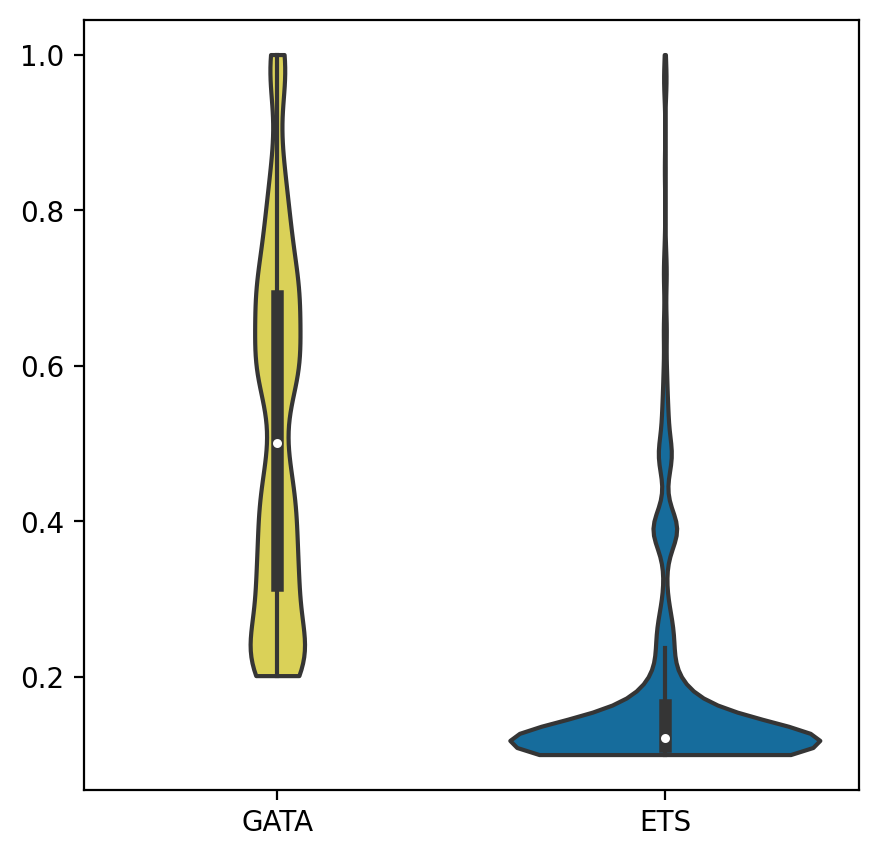

In [14]:
mg=np.median(individualGataAffs)
me=np.median(individualEtsAffs)

fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)
sns.violinplot(data=[individualGataAffs,individualEtsAffs],palette=[cb['yellow'],cb['blue']],cut=0,scale='area')

ax.set_xticklabels(['GATA','ETS'])

ax.scatter(0,mg,s=5,color='white',zorder=100)

ax.scatter(1,me,s=5,color='white',zorder=100)

print('individual affinities over all 3/4site clusters')
print('gata',mg)
print('ets',me)

ax.set_xlim(-.5,1.5)


individual affinities over all 3/4site clusters
GATA - Inert  0.46672762121609224
GATA - Active 0.5756948759940828
ETS  - Inert  0.12143367604990653
ETS  - Active 0.12150918495432608


(-0.5, 3.5)

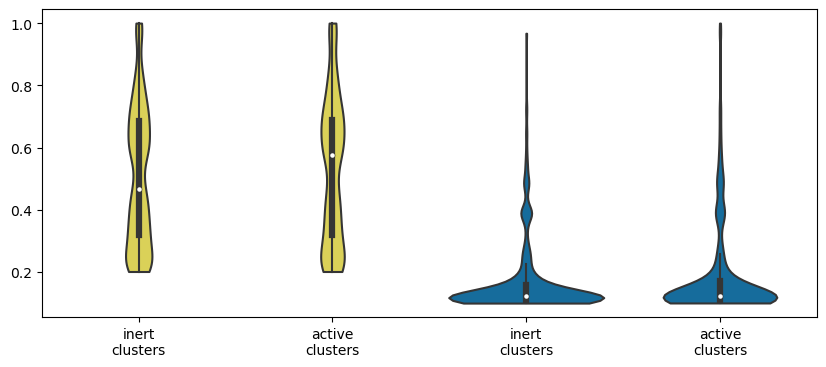

In [15]:
listgA=activity2tf2affs[1]['G']
listeA=activity2tf2affs[1]['E']
listgI=activity2tf2affs[0]['G']
listeI=activity2tf2affs[0]['E']

mgA=np.median(listgA)
meA=np.median(listeA)
mgI=np.median(listgI)
meI=np.median(listeI)

fig,ax=plt.subplots(1,figsize=(10,4))

sns.violinplot(data=[listgI,listgA,listeI,listeA],palette=[cb['yellow'],cb['yellow'],cb['blue'],cb['blue']],cut=0,scale='area')

ax.set_xticklabels(['inert\nclusters','active\nclusters','inert\nclusters','active\nclusters'])

ax.scatter(0,mgI,s=5,color='white',zorder=100)
ax.scatter(1,mgA,s=5,color='white',zorder=100)
ax.scatter(2,meI,s=5,color='white',zorder=100)
ax.scatter(3,meA,s=5,color='white',zorder=100)

print('individual affinities over all 3/4site clusters')
print('GATA - Inert ',mgI)
print('GATA - Active',mgA)
print('ETS  - Inert ', meI)
print('ETS  - Active', meA)

ax.set_xlim(-.5,3.5)


1.526067368133984e-07
0.6238334710532069
0.0009165251198862718


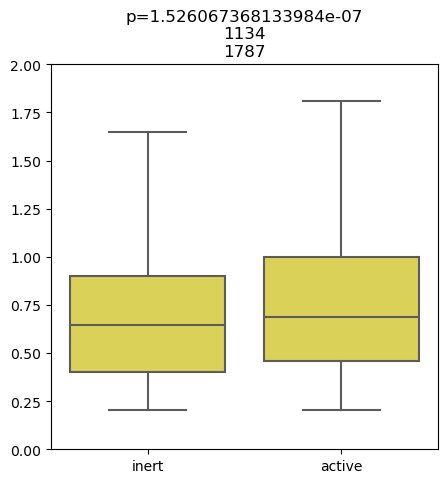

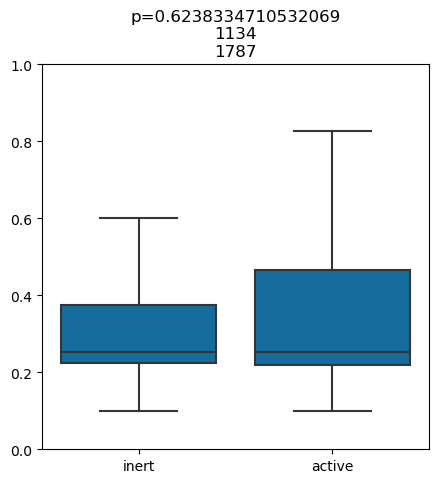

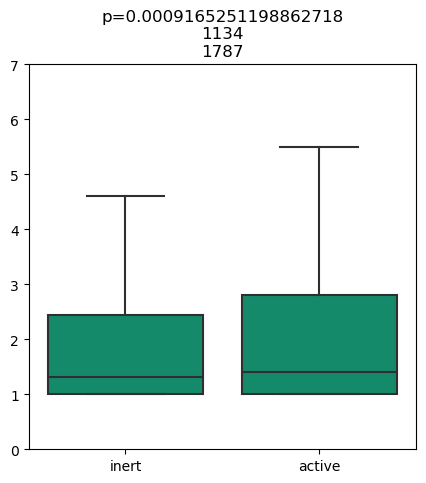

In [16]:
activeEns=df['activity']>=1
inertSeqs=df['activity']<=0

for col,color,ymax in [('gata-aggaff',cb['yellow'],2),('ets-aggaff',cb['blue'],1),('syntax-score',cb['green'],7)]:

    adata=df.loc[activeEns,col].dropna()
    idata=df.loc[inertSeqs,col].dropna()

    p=stats.mannwhitneyu(adata, idata)[1]
    print(p)

    fig,ax=plt.subplots(1,figsize=(5,5))

    sns.boxplot(data=[idata,adata],color=color,fliersize=0)

    ax.set_xticks([0,1],labels=['inert','active'])

    ax.set_title(f'p={p}\n{len(adata)}\n{len(idata)}')
    ax.set_ylim(0,ymax)
    

# Generate data for genome cluster heatmaps

In [17]:
iter2xyz2activitylist={}
iter2xy2activitylist={}

activityThreshold=1
inertThreshold=0

numiters=1000
for iternum in range(numiters):
    
    print(iternum,end=', ')

    # permute dataset
    perm_df=df.copy(deep=True)
    
    permutedActivityLabels=np.random.permutation(perm_df['activity'])
    perm_df['activity']=permutedActivityLabels

    heatType='activity'
    
    activityAggFunc,activityAggFuncStr=np.mean,'mean'

    iter2xyz2activitylist[iternum]={}
    iter2xy2activitylist[iternum]={}

    for gbin,ebin,activity,gscore in zipdf(perm_df,['gata-aggaff-bin','ets-aggaff-bin','activity','syntax-score-bin']):

        if any([pd.isnull(i) for i in [gbin,ebin,activity,gscore]]):
            continue

        xy=(gbin,ebin)
        xyz=(gbin,ebin,gscore)
    

        if xyz not in iter2xyz2activitylist[iternum]:
            iter2xyz2activitylist[iternum][xyz]=[]
            
        if xy not in iter2xy2activitylist[iternum]:
            iter2xy2activitylist[iternum][xy]=[]
            
        iter2xyz2activitylist[iternum][xyz].append(activity)
        iter2xy2activitylist[iternum][xy].append(activity)



0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 

In [18]:
# determine mean annd std stats

iter2xyz2avg={}
iter2xy2avg={}

iter2xyz2pctFuncEns={}

for i in iter2xyz2activitylist:
    
    iter2xyz2avg[i]={}
    iter2xy2avg[i]={}
    
    iter2xyz2pctFuncEns[i]={}
    
    xyz2activitylist=iter2xyz2activitylist[i]
    
    for xyz,alist in xyz2activitylist.items():
        
        avg=np.mean(alist)
        iter2xyz2avg[i][xyz]=avg
        
        numEns=sum([i>=activityThreshold for i in alist])
        numInert=sum([i<=inertThreshold for i in alist])

        if numEns+numInert==0: continue
        iter2xyz2pctFuncEns[i][xyz]=100*numEns/(numEns+numInert)
        

In [19]:
xyz2avg={}
xyz2std={}

xyz2avgpct={}
xyz2stdpct={}

for xyz in iter2xyz2avg[0]:
    
    allVals=[]
    allValsPercents=[]
    
    for iternum in iter2xyz2avg:

        if xyz in iter2xyz2pctFuncEns[iternum]:
            allVals.append(iter2xyz2avg[iternum][xyz])
            allValsPercents.append(iter2xyz2pctFuncEns[iternum][xyz])
        
    xyz2avg[xyz]=np.mean(allVals)
    xyz2std[xyz]=np.std(allVals)
    
    xyz2avgpct[xyz]=np.mean(allValsPercents)
    xyz2stdpct[xyz]=np.std(allValsPercents)
    

In [20]:
xy2avg={}
xy2std={}

for xy in iter2xy2avg[0]:
    
    allVals=[]
    
    for iternum in iter2xy2avg:
        
        allVals.append(iter2xy2avg[iternum][xy])
        
    xy2avg[xy]=np.mean(allVals)
    xy2std[xy]=np.std(allVals)

In [21]:

heatType='activity'

activityAggFunc,activityAggFuncStr=np.mean,'mean'

xyz2count={}
xyz2count_inert={}
xyz2activitylist={}

xy2activitylist={}

for gbin,ebin,activity,gscore in zipdf(df,['gata-aggaff-bin','ets-aggaff-bin','activity','syntax-score-bin']):



    if any([pd.isnull(i) for i in [gbin,ebin,activity,gscore]]):
        continue

    xyz=(gbin,ebin,gscore)
        
    if activity>=activityThreshold:
        if xyz not in xyz2count:
            xyz2count[xyz]=0
        xyz2count[xyz]+=1

    elif activity<=inertThreshold:
        if xyz not in xyz2count_inert:
            xyz2count_inert[xyz]=0
        xyz2count_inert[xyz]+=1
        
    if xyz not in xyz2activitylist:
        xyz2activitylist[xyz]=[]
    xyz2activitylist[xyz].append(activity)
    
    xy=(gbin,ebin)
    if xy not in xy2activitylist:
        xy2activitylist[xy]=[]
    xy2activitylist[xy].append(activity)

xyz2pctFuncEns={}
for xyz,alist in xyz2activitylist.items():
    numEns=sum([ai>=activityThreshold for ai in alist])
    numInert=sum([ai<=inertThreshold for ai in alist])
    if numEns+numInert==0: 
        xyz2pctFuncEns[xyz]=0
    else:
        xyz2pctFuncEns[xyz]=100*numEns/(numEns+numInert)

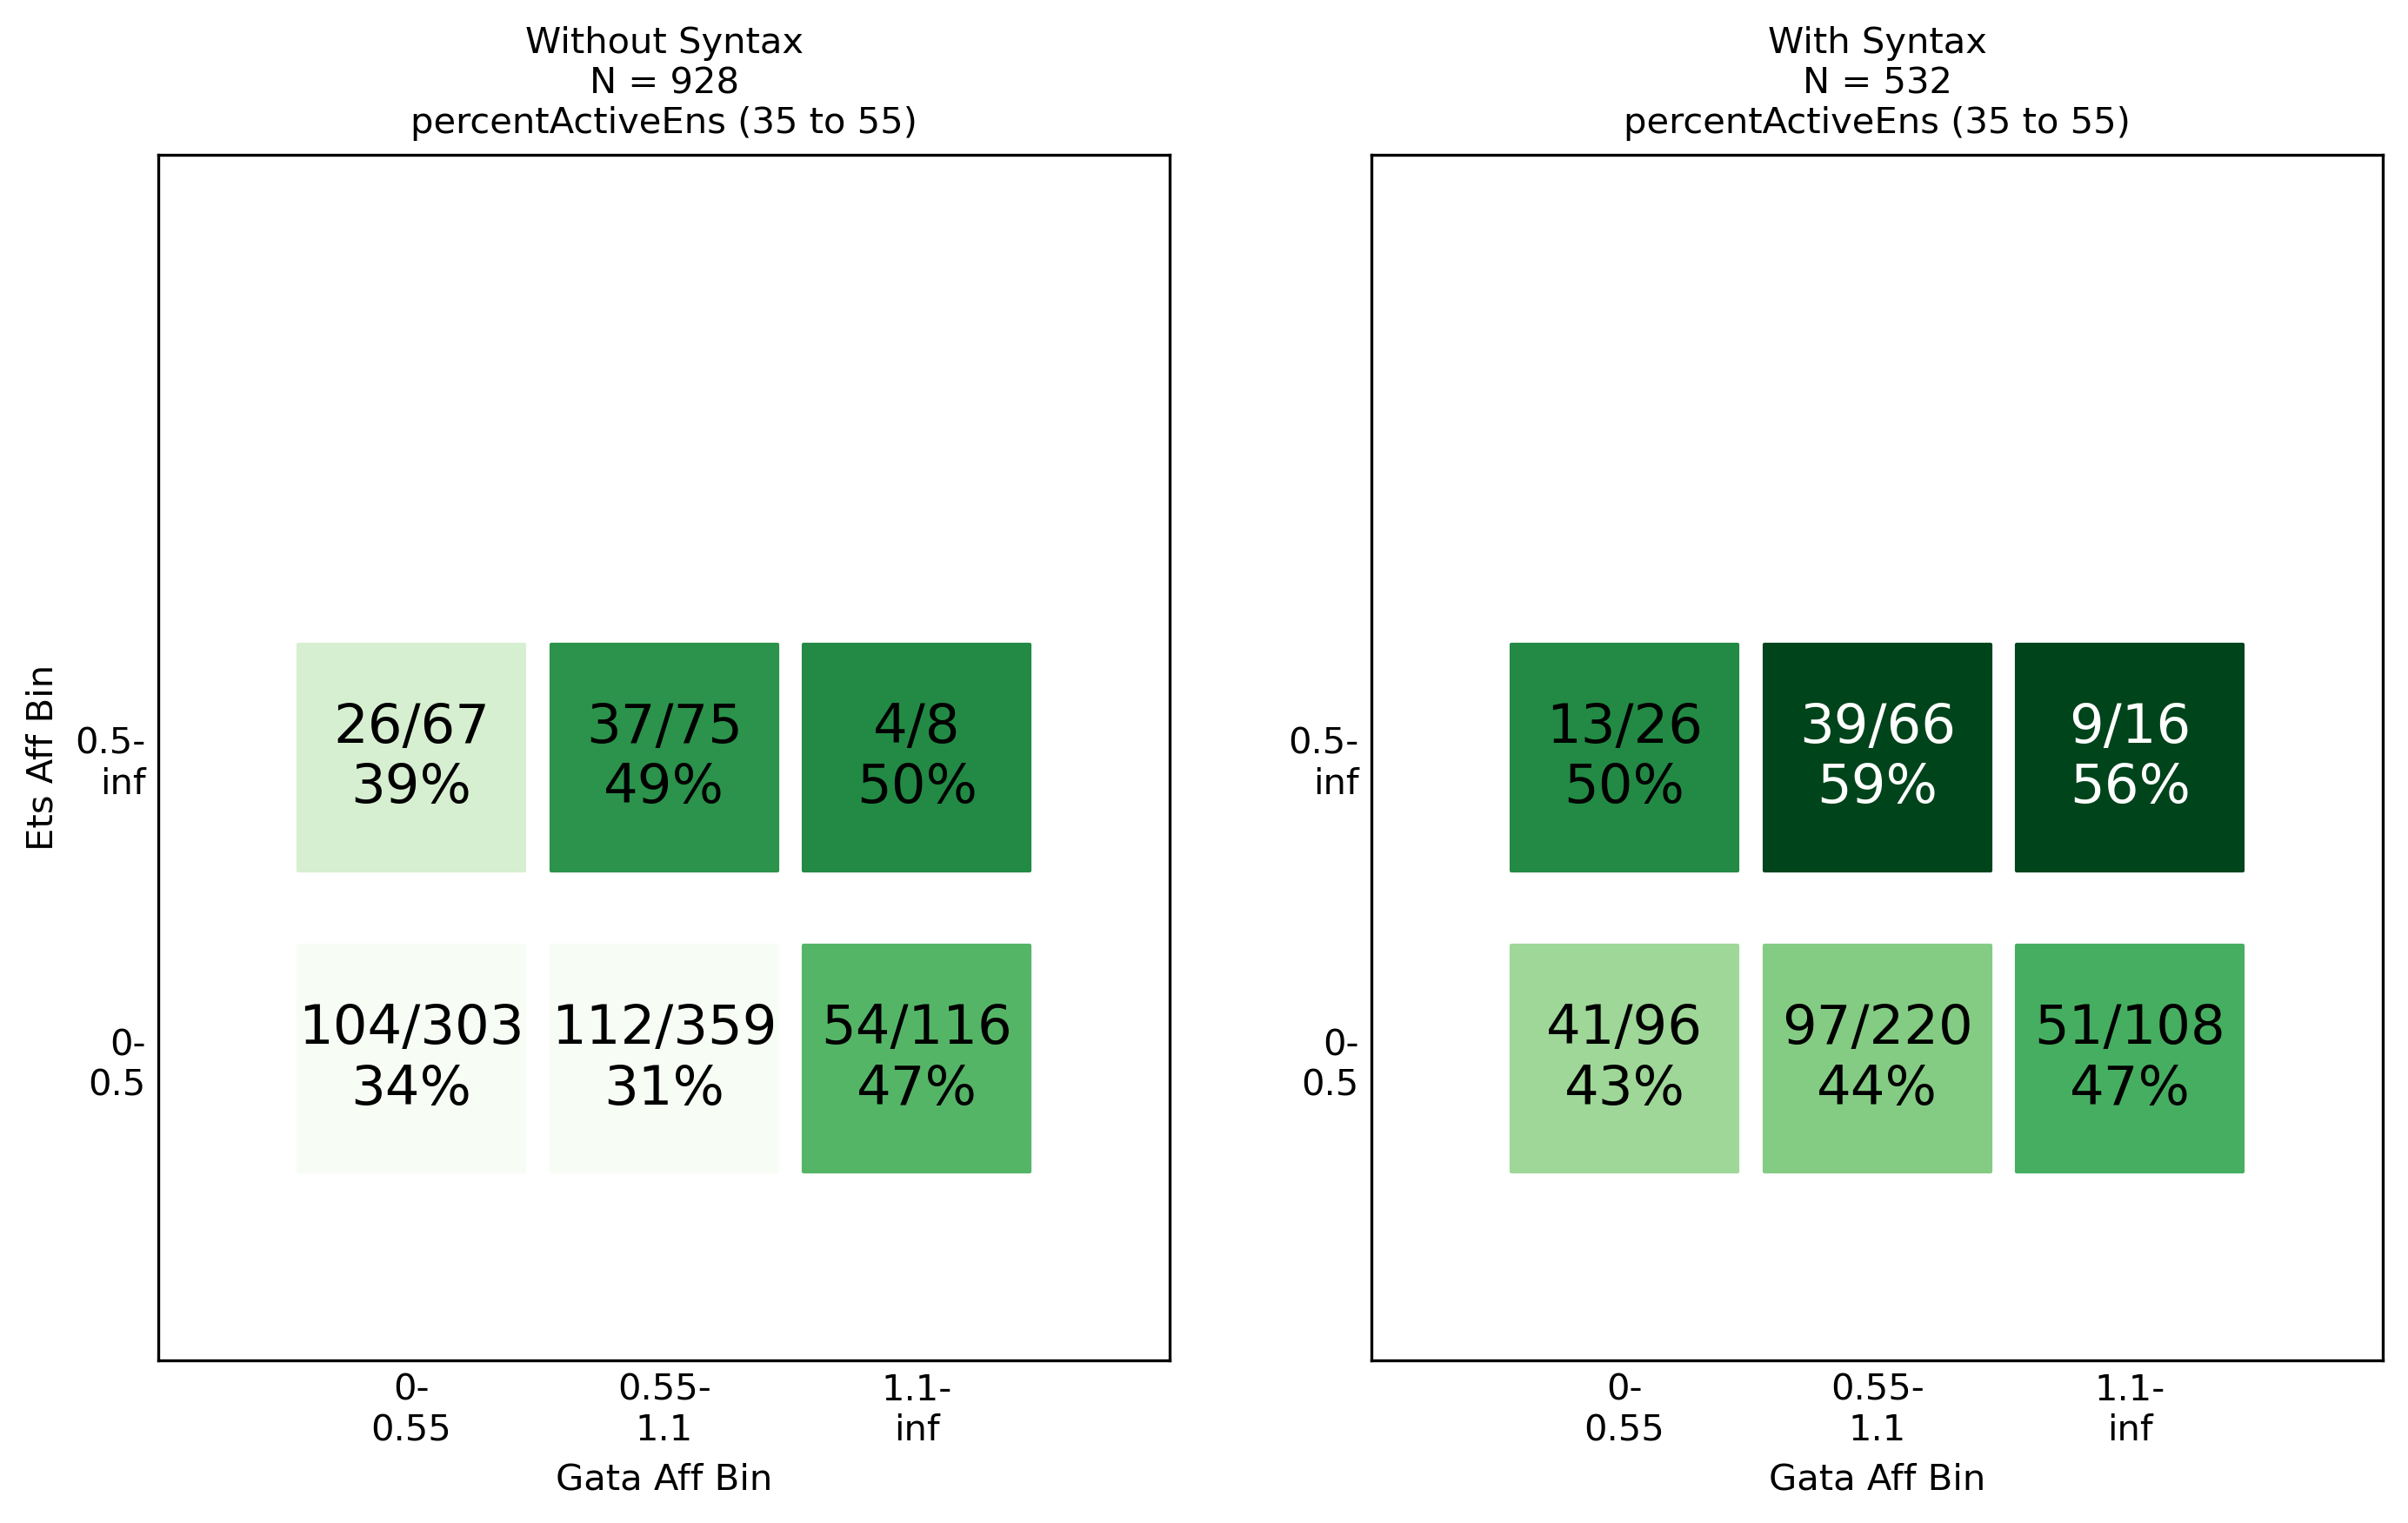

In [22]:

minElementPerCell=0

scaleDotSizeByPvalue=False

shapeDotByPvalue=False

intensityType='percentActiveEns'

csfont = {'fontname':'Helvetica'}

zStackList=sorted(df['syntax-score-bin'].unique())

ncols=len(zStackList)

fig,ax = plt.subplots(1,2,figsize=(ncols*3+2,6),dpi=300)

minCellN=0

allPlottedIntensities=[]

axmin,axmax=-1 ,len(affbinsets) 

xy2alist={}

for plottedGrammarBin,axi,binLabel in [(0,0,'Without Syntax'),(2,1,'With Syntax')]:

    levelN=0
    for (gbin,ebin,gscore),count_func in xyz2count.items():

        # skip z axes that arent in this plane
        if gscore!=plottedGrammarBin: continue

        # get xyz coords
        xyz=(gbin,ebin,gscore)    

        # add data to collapsed heatmap (containing all syntaxes)
        if (gbin,ebin) not in xy2alist:
            xy2alist[gbin,ebin]=[]
        xy2alist[gbin,ebin]+=xyz2activitylist[xyz]

        # tally  how manyactive  and inert in each bin
        ta=sum([a>=activityThreshold for a in xyz2activitylist[xyz]])  # active
        ti=sum([a<=inertThreshold for a in xyz2activitylist[xyz]]) # inert
        t_tot=ta+ti
        obs_pct_active=round(100*ta/t_tot)

        # add total count of heatmap
        levelN+=t_tot

        ##########################################################
        # determine color of square
        ##########################################################

        # determine pvalue
        if intensityType=='percentActiveEns':                intensity=100*ta/(t_tot)
        elif intensityType=='fisherP':                       intensity=fisherP
        else: raise ValueError('intensityType not supported')

        allPlottedIntensities.append(intensity)

        if intensityType=='percentActiveEns': 
            vmin,vmax=35,55
            vwhitetext=50
            cmap='Greens'

        elif intensityType=='fisherP': 
            vmin,vmax=.05,.3
            vwhitetext=.1
            cmap='Blues_r'

        else: raise ValueError('intensityType not supported')

        # plot heatmap point
        if t_tot>=minElementPerCell: 
            
            ######################################################
            # plotting cells
            ######################################################

            # size of dot
            if   scaleDotSizeByPvalue==False:                
                size=3900
            elif scaleDotSizeByPvalue=='percentActiveEns':   
                size=450+2/xyz2pctpvalue[xyz]

            # string plotted
            percentA=round(100*ta/t_tot)
            string=f'{ta}/{t_tot}\n{percentA}%'

            # box
            mappable=ax[axi].scatter(gbin,ebin,marker='s',s=size,c=intensity,cmap=cmap,vmin=vmin,vmax=vmax)

            # star if significant
            if shapeDotByPvalue==True:
                if xyz2pctpvalue[xyz]<.05:
                    mappable=ax[axi].scatter(gbin,ebin,marker='D',s=size,c=intensity,cmap=cmap,vmin=vmin,vmax=vmax)

            ######################################################
            # text in cells
            ######################################################

            # text color
            if '_r' in cmap:
                if intensity<vwhitetext: textcolor='white'
                else:                    textcolor='black'
            else:
                if intensity>vwhitetext: textcolor='white'
                else:                    textcolor='black'

            celltextsize=15
            ax[axi].text(gbin,ebin,string,ha='center',va='center',size=celltextsize,color=textcolor)
            
        ax[axi].set_ylim(axmin,axmax)
        ax[axi].set_xlim(axmin,axmax)
        
        title=f'{binLabel}\nN = {levelN:,}\n{intensityType} ({vmin} to {vmax})'
        
        ax[axi].set_title(title,size=10)

        ax[axi].set_xlabel('Gata Aff Bin')

        if axi==0:
            ax[axi].set_ylabel('Ets Aff Bin')

        ax[axi].set_yticks(range(len(affbinsets) -1) ,labels=[i.replace('-','-\n') for i in affbinsetslabels])
        ax[axi].set_xticks(range(len(affbinsgata)-1) ,labels=[i.replace('-','-\n') for i in affbinsgatalabels])

        ax[axi].tick_params(axis='both', which='both', length=0)


# Comparing elements with and without syntax

In [25]:
yIs='∆%'

##############################
# get all bin info
##############################

xySet=set()
zSet=set()
for xyz in xyz2pctFuncEns:
    x,y,z=xyz
    xySet.add((x,y))
    zSet.add(z)

lowSyntax=min(zSet)
highSyntax=max(zSet)

# real data
ylist=[]

ylistNoSyn=[]
ylistHighSyn=[]

for x,y in sorted(xySet):
    if ((x,y,highSyntax) not in xyz2pctFuncEns) or ((x,y,lowSyntax) not in xyz2pctFuncEns): continue
    
    if (len(xyz2activitylist[x,y,highSyntax])<20) or (len(xyz2activitylist[x,y,lowSyntax])<20): continue
    
    if   yIs=='FC':  yi=xyz2pctFuncEns[x,y,highSyntax]/xyz2pctFuncEns[x,y,lowSyntax]
    elif yIs=='∆%':  yi=xyz2pctFuncEns[x,y,highSyntax]-xyz2pctFuncEns[x,y,lowSyntax]
    elif yIs=='% Increase': 
        end=xyz2pctFuncEns[x,y,highSyntax]
        start=xyz2pctFuncEns[x,y,lowSyntax]
        yi=100*(end-start)/start
    
    ylist.append(yi)
    ylistNoSyn.append(xyz2pctFuncEns[x,y,lowSyntax])
    ylistHighSyn.append(xyz2pctFuncEns[x,y,highSyntax])

[Text(0, 0, 'Without Syntax'), Text(1, 0, 'With Syntax')]

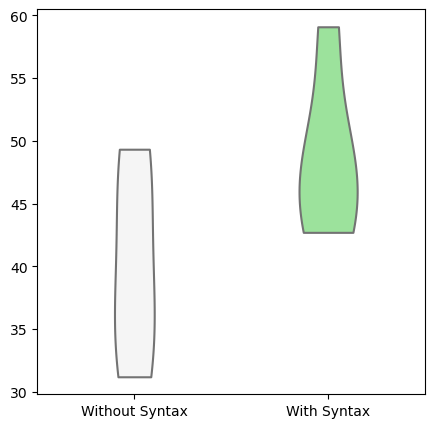

In [26]:
##############################
# plot % active enhancers raw
##############################
    
fig,ax=plt.subplots(1,figsize=(5,5),dpi=100)

xjittermax=0

scatter=False

violin=True
box=False

lines=False


for xi,(ylistIterplot,color) in enumerate([(ylistNoSyn,'grey'),(ylistHighSyn,cb['green'])]):

    for yi in ylistIterplot:

        xjitter=np.random.uniform(-xjittermax,xjittermax)
        if scatter: ax.scatter(xi+xjitter,yi,color=color,zorder=100)

if lines:
    for x,y in xySet:
        if ((x,y,0) in xyz2pctFuncEns) and ((x,y,2) in xyz2pctFuncEns): 
            
            if (len(xyz2activitylist[x,y,0])>=20) &  (len(xyz2activitylist[x,y,2])>=20): 
                nosyn   = xyz2pctFuncEns[x,y,0]
                withsyn = xyz2pctFuncEns[x,y,2]
                ax.plot([0,1],[nosyn,withsyn],color=cb['green'],alpha=.2)
    
if box:       sns.boxplot(data=[ylistNoSyn,ylistHighSyn],fliersize=0,palette=['whitesmoke','lightgreen'],width=.3)
if violin:    sns.violinplot(data=[ylistNoSyn,ylistHighSyn],palette=['whitesmoke','lightgreen'],width=.3,cut=0,inner=None)

ax.set_xticklabels(['Without Syntax','With Syntax'])